## 1. Imports

In [1]:
import gc, os, json, random, warnings, logging
warnings.filterwarnings("ignore", message="Found .* module\\(s\\) in eval mode")
logging.getLogger("transformers.generation.utils").setLevel(logging.ERROR)

from pathlib import Path
from collections import Counter

import torch
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.callbacks import TQDMProgressBar

from torch.utils.data import Dataset, DataLoader
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    get_linear_schedule_with_warmup,
)
import evaluate as hf_evaluate

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

pl.seed_everything(42, workers=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    torch.set_float32_matmul_precision("high")
    print(f"GPU: {torch.cuda.get_device_name(0)}  |  VRAM: {props.total_memory / 1e9:.1f} GB")

Seed set to 42


Device: cuda
GPU: NVIDIA GeForce RTX 4060  |  VRAM: 8.2 GB


## 2. Config

In [2]:
BASE_DIR     = Path("dataset")
MODEL_NAME   = "openai/whisper-small"
LANGUAGE     = "ukrainian"
TASK         = "transcribe"
SAMPLE_RATE  = 16_000
MAX_DURATION = 30

BATCH_SIZE   = 2
GRAD_ACCUM   = 16
LR           = 1e-5
MAX_EPOCHS   = 20
NUM_WORKERS  = 4
VAL_SPLIT    = 0.1

TEST_IDS = {
    "toronto_27",  "toronto_46",  "toronto_42",  "toronto_37",  "toronto_89",
    "toronto_43",  "toronto_157", "toronto_9",   "toronto_156", "toronto_7",
    "toronto_123", "toronto_54",  "toronto_67",  "toronto_62",  "toronto_81",
    "toronto_134", "toronto_148", "toronto_21",  "toronto_135", "toronto_166",
    "toronto_58",
}


## 3. Load labels, filter to files that exist on disk

In [3]:
with open(BASE_DIR / "labels.jsonl") as f:
    raw_labels = json.load(f)

samples = []
for key, transcript in raw_labels.items():
    rel  = key.replace("dataset/", "", 1)
    path = BASE_DIR / rel
    if not path.exists() or not transcript.strip():
        continue
    folder = rel.split("/")[0]
    samples.append({
        "path":       str(path),
        "transcript": transcript.strip(),
        "folder":     folder,
        "split":      "test" if folder in TEST_IDS else "train",
    })

train_samples = [s for s in samples if s["split"] == "train"]
test_samples  = [s for s in samples if s["split"] == "test"]

print(f"Total valid: {len(samples)}  |  Train: {len(train_samples)}  |  Test: {len(test_samples)}")
print(f"Skipped (missing file / empty transcript): {len(raw_labels) - len(samples)}")


Total valid: 18199  |  Train: 12682  |  Test: 5517
Skipped (missing file / empty transcript): 11033


## 4. Preload all audio into RAM

In [4]:
MAX_SAMPLES = MAX_DURATION * SAMPLE_RATE

for s in tqdm(samples, desc="Loading audio"):
    audio, _ = librosa.load(s["path"], sr=SAMPLE_RATE, mono=True)
    s["audio"]    = audio.astype(np.float32)
    s["duration"] = len(audio) / SAMPLE_RATE

ram_gb = sum(s["audio"].nbytes for s in samples) / 1e9
print(f"Done. RAM used by audio: {ram_gb:.2f} GB")

Loading audio:   0%|          | 0/18199 [00:00<?, ?it/s]

Done. RAM used by audio: 6.94 GB


## 5.  EDA - overview


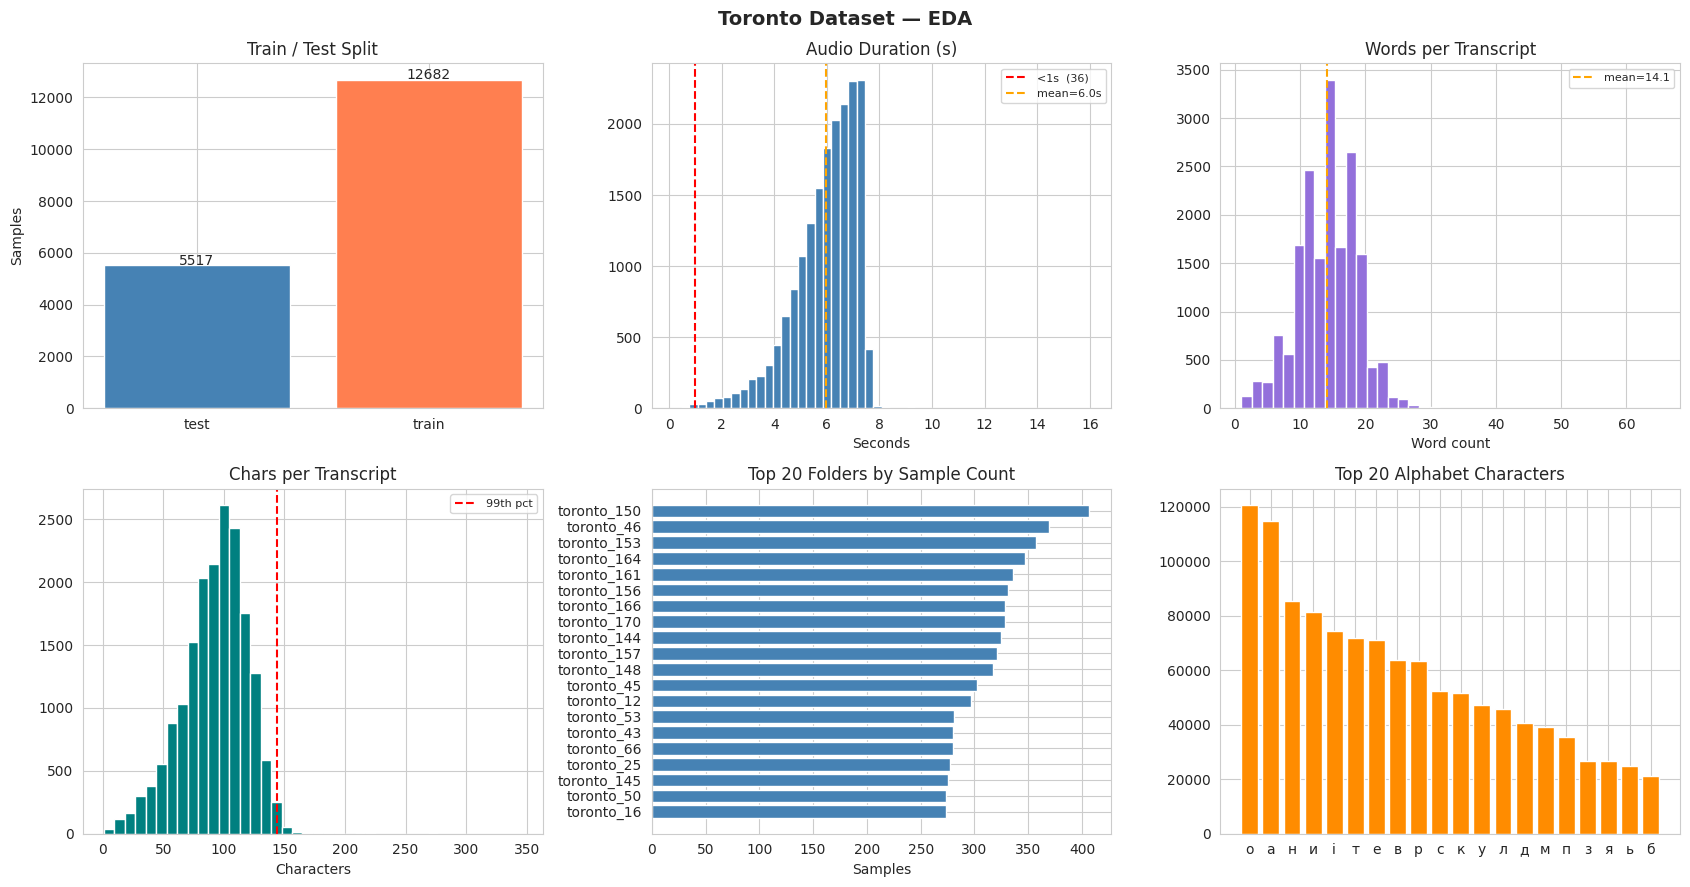

In [5]:
sns.set_style("whitegrid")

durations   = [s["duration"]              for s in samples]
word_counts = [len(s["transcript"].split()) for s in samples]
char_counts = [len(s["transcript"])         for s in samples]
all_text    = " ".join(s["transcript"]      for s in samples)
char_freq   = Counter(c for c in all_text if c.isalpha())
folder_cnt  = Counter(s["folder"]           for s in samples)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
fig.suptitle("Toronto Dataset — EDA", fontsize=14, fontweight="bold")

# train / test bar
split_cnt = Counter(s["split"] for s in samples)
axes[0, 0].bar(split_cnt.keys(), split_cnt.values(), color=["steelblue", "coral"], edgecolor="white")
axes[0, 0].set_title("Train / Test Split")
axes[0, 0].set_ylabel("Samples")
for bar, v in zip(axes[0, 0].patches, split_cnt.values()):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                    str(v), ha="center", fontsize=10)

# duration distribution — highlight short clips as a narrow space
n_short = sum(d < 1.0 for d in durations)
n_long  = sum(d > 30  for d in durations)
axes[0, 1].hist(durations, bins=50, color="steelblue", edgecolor="white")
axes[0, 1].axvline(1.0,              color="red",    linestyle="--", lw=1.5, label=f"<1s  ({n_short})")
axes[0, 1].axvline(np.mean(durations), color="orange", linestyle="--", lw=1.5,
                   label=f"mean={np.mean(durations):.1f}s")
axes[0, 1].set_title("Audio Duration (s)")
axes[0, 1].set_xlabel("Seconds")
axes[0, 1].legend(fontsize=8)

# word count per transcript
axes[0, 2].hist(word_counts, bins=40, color="mediumpurple", edgecolor="white")
axes[0, 2].axvline(np.mean(word_counts), color="orange", linestyle="--",
                   label=f"mean={np.mean(word_counts):.1f}")
axes[0, 2].set_title("Words per Transcript")
axes[0, 2].set_xlabel("Word count")
axes[0, 2].legend(fontsize=8)

# character count — flag potential tokenizer truncation
axes[1, 0].hist(char_counts, bins=40, color="teal", edgecolor="white")
axes[1, 0].axvline(np.percentile(char_counts, 99), color="red", linestyle="--",
                   label="99th pct")
axes[1, 0].set_title("Chars per Transcript")
axes[1, 0].set_xlabel("Characters")
axes[1, 0].legend(fontsize=8)

# samples per folder (top 20) — reveals speaker/session imbalance
top20 = folder_cnt.most_common(20)
axes[1, 1].barh([t[0] for t in top20], [t[1] for t in top20], color="steelblue")
axes[1, 1].invert_yaxis()
axes[1, 1].set_title("Top 20 Folders by Sample Count")
axes[1, 1].set_xlabel("Samples")

# top alphabet characters
top_chars = char_freq.most_common(20)
axes[1, 2].bar([c[0] for c in top_chars], [c[1] for c in top_chars], color="darkorange")
axes[1, 2].set_title("Top 20 Alphabet Characters")

plt.tight_layout()
plt.savefig("assets/eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. EDA - sample waveform + spectrogram


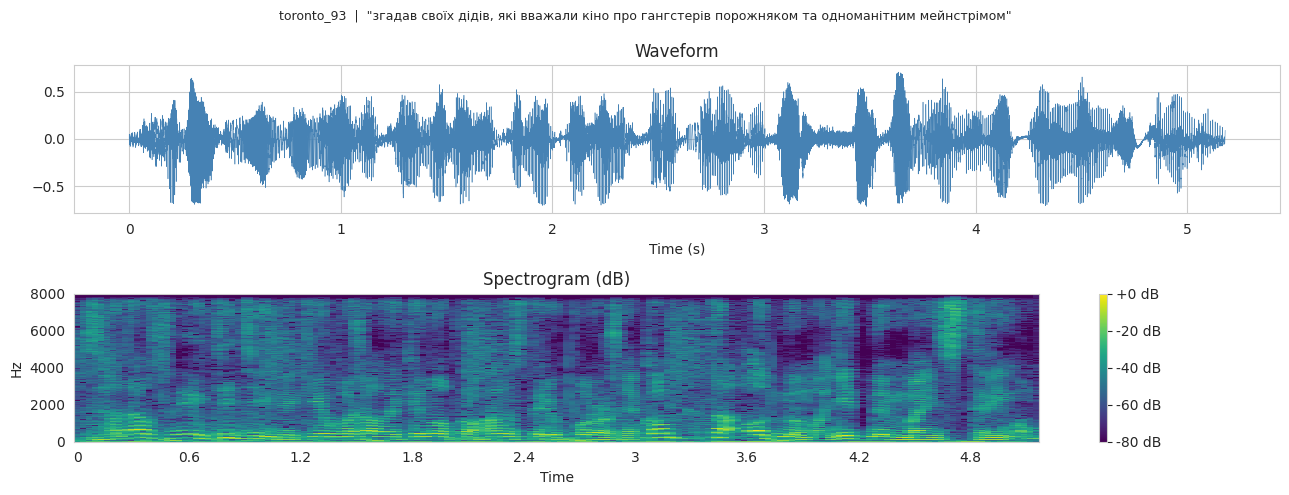

In [6]:
sample = random.choice(train_samples)
audio  = sample["audio"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5))
fig.suptitle(f'{sample["folder"]}  |  "{sample["transcript"][:90]}"', fontsize=9)

ax1.plot(np.linspace(0, sample["duration"], len(audio)), audio, lw=0.4, color="steelblue")
ax1.set_title("Waveform")
ax1.set_xlabel("Time (s)")

D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
img = librosa.display.specshow(D, sr=SAMPLE_RATE, x_axis="time", y_axis="hz",
                               ax=ax2, cmap="viridis")
fig.colorbar(img, ax=ax2, format="%+2.0f dB")
ax2.set_title("Spectrogram (dB)")

plt.tight_layout()
plt.savefig("assets/eda_waveform.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
from IPython.display import display, Audio, HTML

N_LISTEN = 5
listen_samples = random.sample(train_samples, min(N_LISTEN, len(train_samples)))

for i, s in enumerate(listen_samples, 1):
    display(HTML(
        f"<b>Sample {i}/{N_LISTEN}</b> &nbsp;|&nbsp; "
        f"<code>{s['folder']}</code> &nbsp;|&nbsp; {s['duration']:.1f}s<br>"
        f"<i>{s['transcript']}</i>"
    ))
    display(Audio(s["audio"], rate=SAMPLE_RATE))

## 7. EDA - duration vs. words + bottleneck summary


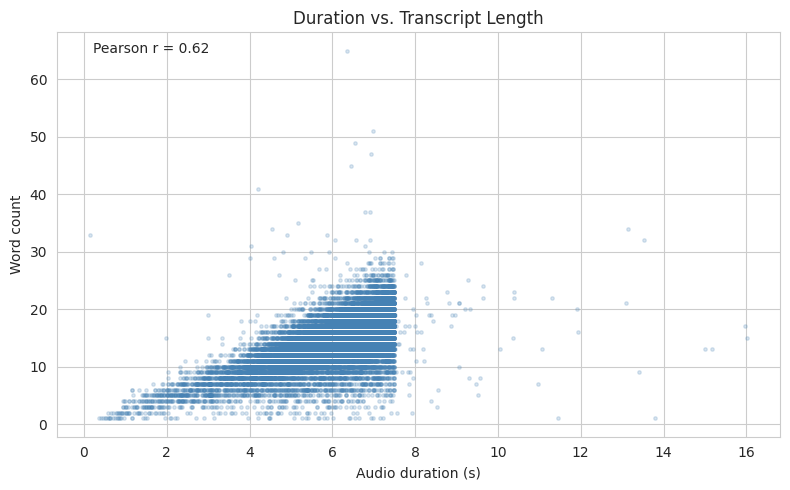

=== Dataset bottlenecks ===
Clips < 1s (too short, Whisper struggles):     36
Clips > 30s (truncated at input):              0
Unique special/digit chars in transcripts:     46  (numbers, punctuation, symbols)
Folder imbalance: max=407, min=43  (9.5x ratio)
Vocabulary size:  68014 unique words
Duration-text corr: 0.62  (low = noisy alignment)


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(durations, word_counts, alpha=0.2, s=6, color="steelblue")
ax.set_xlabel("Audio duration (s)")
ax.set_ylabel("Word count")
ax.set_title("Duration vs. Transcript Length")
corr = np.corrcoef(durations, word_counts)[0, 1]
ax.text(0.05, 0.95, f"Pearson r = {corr:.2f}", transform=ax.transAxes, fontsize=10)
plt.tight_layout()
plt.savefig("assets/eda_duration_vs_words.png", dpi=150, bbox_inches="tight")
plt.show()

# print known bottlenecks
n_special = len(set(c for c in all_text if not c.isalpha() and not c.isspace()))
max_f, min_f = max(folder_cnt.values()), min(folder_cnt.values())
vocab_size  = len(set(w for s in samples for w in s["transcript"].lower().split()))

print("=== Dataset bottlenecks ===")
print(f"Clips < 1s (too short, Whisper struggles):     {n_short}")
print(f"Clips > 30s (truncated at input):              {n_long}")
print(f"Unique special/digit chars in transcripts:     {n_special}  (numbers, punctuation, symbols)")
print(f"Folder imbalance: max={max_f}, min={min_f}  ({max_f/min_f:.1f}x ratio)")
print(f"Vocabulary size:  {vocab_size} unique words")
print(f"Duration-text corr: {corr:.2f}  (low = noisy alignment)")


## 8. Whisper processor


In [9]:
processor = WhisperProcessor.from_pretrained(MODEL_NAME, language=LANGUAGE, task=TASK)

Tokenizing train transcripts for token-length EDA...


Tokenizing:   0%|          | 0/12682 [00:00<?, ?it/s]


=== Token length percentiles (train set) ===
  p 50:   47 tokens
  p 75:   54 tokens
  p 90:   60 tokens
  p 95:   63 tokens
  p 99:   69 tokens
  p100:  155 tokens
  mean: 45.9  |  max: 155


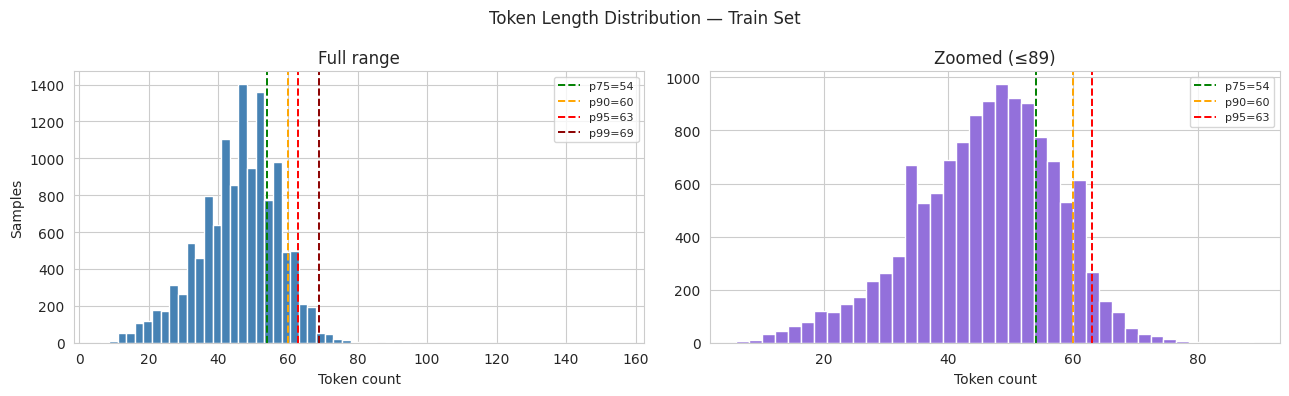


Recommended MAX_TOKENS (p99, covers 99% of train data): 69


In [10]:
print("Tokenizing train transcripts for token-length EDA...")
train_token_lens = []
for s in tqdm(train_samples, desc="Tokenizing"):
    ids = processor.tokenizer(s["transcript"]).input_ids
    train_token_lens.append(len(ids))

token_arr  = np.array(train_token_lens)
pcts       = [50, 75, 90, 95, 99, 100]
pct_values = np.percentile(token_arr, pcts)

print("\n=== Token length percentiles (train set) ===")
for p, v in zip(pcts, pct_values):
    print(f"  p{p:3d}: {int(v):4d} tokens")
print(f"  mean: {token_arr.mean():.1f}  |  max: {token_arr.max()}")

# histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Token Length Distribution — Train Set", fontsize=12)

axes[0].hist(token_arr, bins=60, color="steelblue", edgecolor="white")
for p, v, col in zip([75, 90, 95, 99], pct_values[1:5],
                     ["green", "orange", "red", "darkred"]):
    axes[0].axvline(v, color=col, linestyle="--", lw=1.4, label=f"p{p}={int(v)}")
axes[0].set_xlabel("Token count")
axes[0].set_ylabel("Samples")
axes[0].set_title("Full range")
axes[0].legend(fontsize=8)

cutoff = int(pct_values[4]) + 20   # zoom to p99 + margin
axes[1].hist(token_arr[token_arr <= cutoff], bins=40, color="mediumpurple", edgecolor="white")
axes[1].set_xlabel("Token count")
axes[1].set_title(f"Zoomed (≤{cutoff})")
for p, v, col in zip([75, 90, 95], pct_values[1:4],
                     ["green", "orange", "red"]):
    axes[1].axvline(v, color=col, linestyle="--", lw=1.4, label=f"p{p}={int(v)}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("assets/eda_token_lengths.png", dpi=150, bbox_inches="tight")
plt.show()

recommended = int(np.percentile(token_arr, 99))
print(f"\nRecommended MAX_TOKENS (p99, covers 99% of train data): {recommended}")

MAX_TOKENS   = recommended

## 9. Dataset + DataModule


In [11]:
class TorontoDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s     = self.samples[idx]
        audio = s["audio"][:MAX_SAMPLES]        # hard clip at 30s

        input_features = processor.feature_extractor(
            audio, sampling_rate=SAMPLE_RATE, return_tensors="pt"
        ).input_features[0]

        labels = processor.tokenizer(
            s["transcript"], return_tensors="pt", truncation=True, max_length=448
        ).input_ids[0]

        return {"input_features": input_features, "labels": labels}


def collate_fn(batch):
    features = torch.stack([b["input_features"] for b in batch])
    labels   = [b["labels"] for b in batch]
    max_len  = max(l.size(0) for l in labels)
    padded   = torch.full((len(labels), max_len), -100, dtype=torch.long)
    for i, l in enumerate(labels):
        padded[i, : l.size(0)] = l
    return {"input_features": features, "labels": padded}


class TorontoDataModule(pl.LightningDataModule):
    def __init__(self, train_samples, test_samples):
        super().__init__()
        self.train_samples = train_samples
        self.test_samples  = test_samples

    def setup(self, stage=None):
        shuffled = self.train_samples.copy()
        random.shuffle(shuffled)
        n_val            = int(len(shuffled) * VAL_SPLIT)
        self.train_ds    = TorontoDataset(shuffled[n_val:])
        self.val_ds      = TorontoDataset(shuffled[:n_val])
        self.test_ds     = TorontoDataset(self.test_samples)

    def _loader(self, ds, shuffle=False, stage='train'):  # 👈 ADD stage param
        num_workers = 0 if os.name == "nt" else NUM_WORKERS
        
        persistent_workers = (NUM_WORKERS > 0 and stage != 'test')
        
        return DataLoader(
            ds, 
            batch_size=BATCH_SIZE, 
            shuffle=shuffle,
            collate_fn=collate_fn,
            num_workers=num_workers,
            pin_memory=True,
            persistent_workers=persistent_workers,
            prefetch_factor=2 if num_workers > 0 else None
        )
        
    def train_dataloader(self): 
        return self._loader(self.train_ds, shuffle=True, stage='train')
    
    def val_dataloader(self):   
        return self._loader(self.val_ds, stage='val')
    
    def test_dataloader(self):  
        return self._loader(self.test_ds, stage='test')


## 10. Whisper Module


In [12]:
class WhisperModule(pl.LightningModule):
    def __init__(self, model_name: str = MODEL_NAME):
        super().__init__()
        self.save_hyperparameters()

        self.model = WhisperForConditionalGeneration.from_pretrained(model_name)
        self.model.generation_config.language        = LANGUAGE
        self.model.generation_config.task            = TASK
        self.model.generation_config.max_new_tokens  = MAX_TOKENS

        self._wer          = hf_evaluate.load("wer")
        self._cer          = hf_evaluate.load("cer")
        self._test_outputs = []
        self._val_outputs  = []

    def forward(self, input_features, labels=None):
        return self.model(input_features=input_features, labels=labels)

    def training_step(self, batch, _):
        loss = self(batch["input_features"], batch["labels"]).loss
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        gen = self.model.generate(
            batch["input_features"],
            max_new_tokens=MAX_TOKENS,
            return_timestamps=False
            )
        preds = processor.tokenizer.batch_decode(gen, skip_special_tokens=True)

        lbls = batch["labels"].clone()
        lbls[lbls == -100] = processor.tokenizer.pad_token_id
        refs = processor.tokenizer.batch_decode(lbls, skip_special_tokens=True)

        self._val_outputs.append({"preds": preds, "refs": refs})


    def on_validation_epoch_end(self):
        all_preds = [p for o in self._val_outputs for p in o["preds"]]
        all_refs  = [r for o in self._val_outputs for r in o["refs"]]

        wer = self._wer.compute(predictions=all_preds, references=all_refs)
        cer = self._cer.compute(predictions=all_preds, references=all_refs)
        self.log("val_wer", wer, on_epoch=True, prog_bar=True, sync_dist=True)
        self.log("val_cer", cer, on_epoch=True, prog_bar=True, sync_dist=True)
        self._val_outputs.clear()
        
    def test_step(self, batch, _):
        gen = self.model.generate(
            batch["input_features"],
            max_new_tokens=MAX_TOKENS,
            return_timestamps=False
            )
        preds = processor.tokenizer.batch_decode(gen, skip_special_tokens=True)

        lbls = batch["labels"].clone()
        lbls[lbls == -100] = processor.tokenizer.pad_token_id
        refs  = processor.tokenizer.batch_decode(lbls, skip_special_tokens=True)

        self._test_outputs.append({"preds": preds, "refs": refs})

    def on_test_epoch_end(self):
        all_preds = [p for o in self._test_outputs for p in o["preds"]]
        all_refs  = [r for o in self._test_outputs for r in o["refs"]]

        wer = self._wer.compute(predictions=all_preds, references=all_refs)
        cer = self._cer.compute(predictions=all_preds, references=all_refs)
        self.log_dict({"test_wer": wer, "test_cer": cer})
        self.print(f"\n{'='*40}")
        self.print(f"Test WER : {wer:.4f}")
        self.print(f"Test CER : {cer:.4f}")
        self.print(f"{'='*40}\n")

        # qualitative sample
        self.print("Sample predictions:")
        for ref, pred in zip(all_refs[:5], all_preds[:5]):
            self.print(f"  REF : {ref}")
            self.print(f"  PRED: {pred}\n")

        self._test_outputs.clear()

    def configure_optimizers(self):
        opt         = torch.optim.AdamW(self.parameters(), lr=LR, weight_decay=0.1)
        total_steps = self.trainer.estimated_stepping_batches
        warmup      = max(100, total_steps // 10)
        sched       = get_linear_schedule_with_warmup(opt, warmup, total_steps)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "interval": "step"}}


## 11.  Train


In [14]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

dm = TorontoDataModule(train_samples, test_samples)
module = WhisperModule()
if int(torch.__version__.split(".")[0]) >= 2:
    module.model = torch.compile(module.model, dynamic=True)

CKPT_DIR  = Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)

checkpoint_cb = ModelCheckpoint(
    dirpath    = CKPT_DIR,
    monitor    = "val_wer",
    mode       = "min",
    save_top_k = 1,
    filename   = MODEL_NAME.replace("/", "_") + "_best"
)
early_stop_cb = EarlyStopping(monitor="val_wer", patience=2, mode="min", verbose=True)

trainer = pl.Trainer(
    max_epochs              = MAX_EPOCHS,
    accelerator             = "gpu" if device == "cuda" else "cpu",
    devices                 = 1,
    precision               = "bf16-mixed",
    accumulate_grad_batches = GRAD_ACCUM,
    gradient_clip_val       = 1.0,
    callbacks               = [checkpoint_cb, early_stop_cb, TQDMProgressBar()],
    log_every_n_steps       = 10,
    logger                  = False,
)

trainer.fit(module, datamodule=dm)

best_ckpt = checkpoint_cb.best_model_path
print(f"\nBest checkpoint saved to: {best_ckpt}")

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/gllekkpc/env/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/gllekkpc/Documents/AudioML_HW_pavlosiuk_denysova/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
/home/gllekkpc/env/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/gllekkpc/env/lib/python3.13/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: 

┏━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type            ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ model │ OptimizedModule │  241 M │ eval │     0 │
└───┴───────┴─────────────────┴────────┴──────┴───────┘

Trainable params: 241 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 241 M                                                                                                
Total estimated model params size (MB): 966                                                                        
Modules in train mode: 0                                                                                           
Modules in eval mode: 351                                                                                          
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Metric val_wer improved by 0.001 >= min_delta = 0.0. New best score: 0.324


Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_wer did not improve in the last 2 records. Best score: 0.324. Signaling Trainer to stop.



Best checkpoint saved to: /home/gllekkpc/Documents/AudioML_HW_pavlosiuk_denysova/checkpoints/openai_whisper-small_best-v1.ckpt


## 12. Evaluate on test data

In [15]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

best = WhisperModule.load_from_checkpoint(best_ckpt, strict=False)
dm_test = TorontoDataModule(train_samples, test_samples)
dm_test.setup()

eval_trainer = pl.Trainer(
    accelerator = "gpu" if device == "cuda" else "cpu",
    devices     = 1,
    precision   = "bf16-mixed",
    logger      = False,
    callbacks=[TQDMProgressBar()]
)
eval_trainer.test(best, datamodule=dm_test)


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

/home/gllekkpc/env/lib/python3.13/site-packages/pytorch_lightning/core/saving.py:193: Found keys that are in the model state dict but not in the checkpoint: ['model.model.encoder.conv1.weight', 'model.model.encoder.conv1.bias', 'model.model.encoder.conv2.weight', 'model.model.encoder.conv2.bias', 'model.model.encoder.embed_positions.weight', 'model.model.encoder.layers.0.self_attn.k_proj.weight', 'model.model.encoder.layers.0.self_attn.v_proj.weight', 'model.model.encoder.layers.0.self_attn.v_proj.bias', 'model.model.encoder.layers.0.self_attn.q_proj.weight', 'model.model.encoder.layers.0.self_attn.q_proj.bias', 'model.model.encoder.layers.0.self_attn.out_proj.weight', 'model.model.encoder.layers.0.self_attn.out_proj.bias', 'model.model.encoder.layers.0.self_attn_layer_norm.weight', 'model.model.encoder.layers.0.self_attn_layer_norm.bias', 'model.model.encoder.layers.0.fc1.weight', 'model.model.encoder.layers.0.fc1.bias', 'model.model.encoder.layers.0.fc2.weight', 'model.model.encoder.

Testing: |          | 0/? [00:00<?, ?it/s]


Test WER : 0.4388
Test CER : 0.1936

Sample predictions:
  REF : Слава Ісу! Ви сі дивите програму «Грати, песик, дужка, гривня, знак питання, долар, нуль» ₴?$0»). Я є її ведучий, Майкл Щур. Вйо до новин!
  PRED:  Слава Іссу! Ви сі дивите програму «Грати, песик, душка, гривня, знак питання, долар нуль». Я є її ведучий Майкл Шчур. Вйо до новин!

  REF : Купол Верховної Ради впав під час засідання, накривши сотні депутатів. Всередині Ради вибухають гранати, все палає, люди кричать,
  PRED:  Купол Верховної Ради впав під час засідання, накривши сотні депутатів. Всередині Ради вибухають гранати, все палає, люди кричать,

  REF : живих добивають з автоматів, кров, вогонь, агонія... і Надія. Народний депутат Надія Савченко. Як стверджує генпрокурор,
  PRED:  Живих додувають з автоматів, кровь, богоня, гоня і надія. Народний депутат Надія Савченко, екстрерджо-генпрокурор

  REF : саме такий теракт вона планувала влаштувати у Верховній Раді. У слідства є незаперечні докази,
  PRED:  А саме так

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_cer          │    0.19356460869312286    │
│         test_wer          │    0.4388440251350403     │
└───────────────────────────┴───────────────────────────┘

[{'test_wer': 0.4388440251350403, 'test_cer': 0.19356460869312286}]